In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
# compiling dfs
folder = Path('./output/classif_grid_5t175c')
subfolders = ['t1', 't2', 't3', 't4', 't5', 't6']

dev = merge_devtest_csvs(folder, subfolders, 'dev.csv')#, save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv')#, save=True)

# get confs, update
confs = ConfigLookup(
    keys=['embed_dim', 'hidden_dims', 'lr'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    # save=True,
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

# add log10lr
dev['log10lr'] = np.log10(dev['lr'])
test['log10lr'] = np.log10(test['lr'])

In [4]:
dev

,embed_dim,hidden_dims,lr,config,trial,epoch,stage,metric,value,log10lr
0,16,0,0.10000,embeddim16_hiddendims0_lr1e-1,0,0,train,loss,1.729085,-1.0
1,16,0,0.10000,embeddim16_hiddendims0_lr1e-1,0,0,train,accuracy,0.132603,-1.0
2,16,0,0.10000,embeddim16_hiddendims0_lr1e-1,0,0,train,precision,0.131820,-1.0
3,16,0,0.10000,embeddim16_hiddendims0_lr1e-1,0,0,train,recall,0.193676,-1.0
4,16,0,0.10000,embeddim16_hiddendims0_lr1e-1,0,0,train,f1,0.140161,-1.0
...,...,...,...,...,...,...,...,...,...,...
629995,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,5,49,val,accuracy,0.417143,-5.0
629996,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,5,49,val,precision,0.366794,-5.0
629997,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,5,49,val,recall,0.376748,-5.0
629998,256,6,0.00001,embeddim256_hiddendims6_lr1e-5,5,49,val,f1,0.351537,-5.0


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='epoch', ylabel='value'>

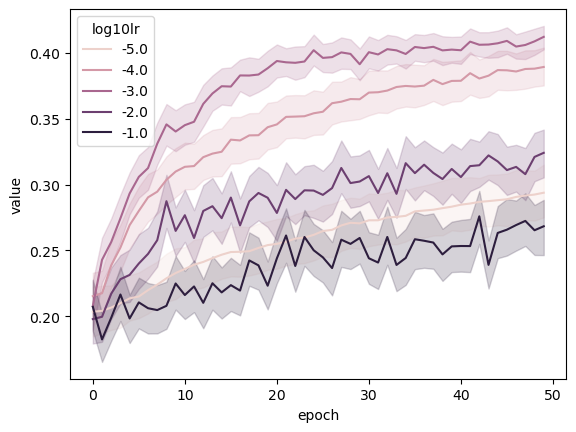

In [ ]:
dev_filt = dev[(dev['stage']=='val') & (dev['metric']=='accuracy')]
sns.lineplot(dev_filt, x='epoch', y='value', hue='log10lr', errorbar='ci')

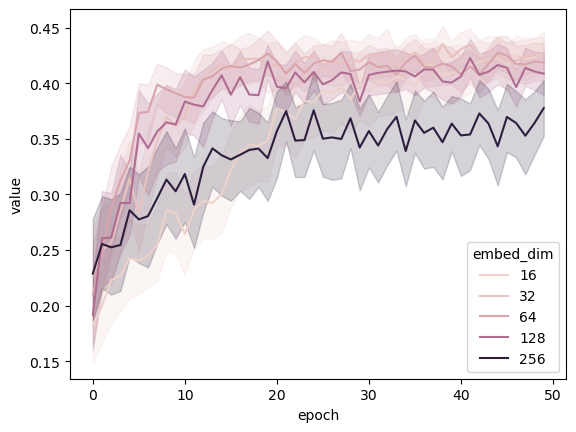

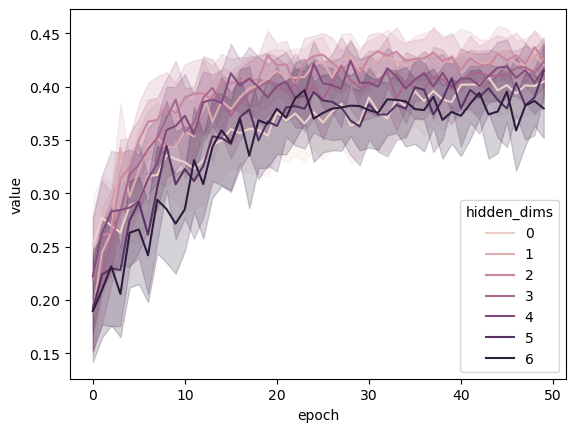

In [29]:
dev_filt = dev[(dev['stage']=='val') & (dev['metric']=='accuracy') & (dev['lr']==1e-3)]
sns.lineplot(dev_filt, x='epoch', y='value', hue='embed_dim', errorbar='ci')
plt.show()

sns.lineplot(dev_filt, x='epoch', y='value', hue='hidden_dims', errorbar='ci')
plt.show()
